# Module 8 — Portfolio Stress Testing

## Objective

This module evaluates how a portfolio may behave under
hypothetical market stress scenarios.

The analysis includes:

1. Portfolio construction
2. Baseline portfolio performance
3. Causal beta estimation
4. Market stress scenarios
5. Beta-based stock-level shocks
6. Portfolio-level losses
7. Stock contribution to portfolio losses
8. Stress scenario comparison
9. Risk visualization

The stress-testing framework is scenario-based and does not
represent a forecast or guarantee of future losses.

In [3]:
# ============================================================
# 1. Imports & Configuration
# ============================================================

import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# Paths
FEATURE_PATH = "../backend/data/feature_engineered_dataset.csv"

# Stress-test date
STRESS_DATE = "2025-12-31"

# Portfolio value for monetary loss calculations
PORTFOLIO_VALUE = 1_000_000

print("Libraries imported successfully.")
print("Feature dataset path:", FEATURE_PATH)
print("Stress-test date:", STRESS_DATE)
print("Portfolio value:", PORTFOLIO_VALUE)

Libraries imported successfully.
Feature dataset path: ../backend/data/feature_engineered_dataset.csv
Stress-test date: 2025-12-31
Portfolio value: 1000000


In [4]:
# ============================================================
# 2. Load Feature-Engineered Dataset
# ============================================================

if not os.path.exists(FEATURE_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {FEATURE_PATH}"
    )

df = pd.read_csv(FEATURE_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Stock", "Date"]
).reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Number of stocks:", df["Stock"].nunique())
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (70764, 37)
Date range: 2020-01-02 to 2025-12-31
Number of stocks: 49

Columns:
['Date', 'Stock', 'Open', 'High', 'Low', 'Close', 'Volume', 'NIFTY_Close', 'VIX_Close', 'Daily_Return', 'Rolling_Volatility_20D', 'Rolling_Volatility_60D', 'MA_20', 'MA_50', 'Price_MA20_Ratio', 'Price_MA50_Ratio', 'Momentum_20D', 'RSI_14', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'Previous_Close', 'TR', 'ATR_14', 'Volatility_Ratio', 'Volume_MA20', 'Volume_Ratio', 'Volume_Change', 'Price_Range', 'High_Low_Pct', 'Gap_Pct', 'NIFTY_Return', 'Beta_Causal', 'Future_Volatility_20D', 'High_Risk']


In [5]:
# ============================================================
# 3. Dataset Validation
# ============================================================

required_columns = [
    "Date",
    "Stock",
    "Close",
    "Daily_Return",
    "Beta_Causal"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

duplicate_count = df.duplicated(
    subset=["Stock", "Date"]
).sum()

invalid_close = (
    (~np.isfinite(df["Close"])) |
    (df["Close"] <= 0)
).sum()

invalid_returns = (
    ~np.isfinite(df["Daily_Return"])
).sum()

invalid_beta = (
    ~np.isfinite(df["Beta_Causal"])
).sum()

print("Required-column check: PASS")
print("Duplicate Stock-Date rows:", duplicate_count)
print("Invalid Close values:", invalid_close)
print("Invalid Daily_Return values:", invalid_returns)
print("Invalid Beta_Causal values:", invalid_beta)

if duplicate_count != 0:
    raise ValueError("Duplicate Stock-Date observations detected.")

if invalid_close != 0:
    raise ValueError("Invalid Close values detected.")

print("\nDataset validation completed.")

Required-column check: PASS
Duplicate Stock-Date rows: 0
Invalid Close values: 0
Invalid Daily_Return values: 49
Invalid Beta_Causal values: 2989

Dataset validation completed.


In [6]:
# ============================================================
# 4. Portfolio Universe and Equal-Weight Construction
# ============================================================

# Use all stocks available in the finalized dataset
portfolio_stocks = sorted(df["Stock"].dropna().unique())

N_STOCKS = len(portfolio_stocks)

if N_STOCKS != 49:
    raise ValueError(
        f"Expected 49 stocks, but found {N_STOCKS}."
    )

# Equal weight for every stock
EQUAL_WEIGHT = 1.0 / N_STOCKS

PORTFOLIO = {
    stock: EQUAL_WEIGHT
    for stock in portfolio_stocks
}

print("Portfolio construction: Equal-weight")
print("Number of stocks:", N_STOCKS)
print("Weight per stock:", f"{EQUAL_WEIGHT:.6%}")
print("Total portfolio weight:", f"{sum(PORTFOLIO.values()):.6f}")

print("\nFirst 10 portfolio stocks:")
for stock, weight in list(PORTFOLIO.items())[:10]:
    print(f"{stock:15s} -> {weight:.6%}")

Portfolio construction: Equal-weight
Number of stocks: 49
Weight per stock: 2.040816%
Total portfolio weight: 1.000000

First 10 portfolio stocks:
ADANIENT        -> 2.040816%
ADANIPORTS      -> 2.040816%
APOLLOHOSP      -> 2.040816%
ASIANPAINT      -> 2.040816%
AXISBANK        -> 2.040816%
BAJAJ-AUTO      -> 2.040816%
BAJAJFINSV      -> 2.040816%
BAJFINANCE      -> 2.040816%
BEL             -> 2.040816%
BHARTIARTL      -> 2.040816%


In [7]:
# Validate portfolio weights

if not np.isclose(sum(PORTFOLIO.values()), 1.0):
    raise ValueError("Portfolio weights must sum to 1.0")

missing_stocks = [
    stock for stock in portfolio_stocks
    if stock not in set(df["Stock"].unique())
]

if missing_stocks:
    raise ValueError(
        f"Portfolio stocks not found in dataset: {missing_stocks}"
    )

print("Portfolio validation: PASS")

Portfolio validation: PASS


In [8]:
# ============================================================
# 5. Create Portfolio Dataset
# ============================================================

portfolio_df = df[
    df["Stock"].isin(portfolio_stocks)
].copy()

portfolio_df["Weight"] = portfolio_df["Stock"].map(PORTFOLIO)

print("Portfolio dataset shape:", portfolio_df.shape)
print("Portfolio stocks:", portfolio_df["Stock"].nunique())

print("\nPortfolio stock coverage:")
print(
    portfolio_df.groupby("Stock")["Date"]
    .agg(["min", "max", "count"])
)

Portfolio dataset shape: (70764, 38)
Portfolio stocks: 49

Portfolio stock coverage:
                  min        max  count
Stock                                  
ADANIENT   2020-01-02 2025-12-31   1470
ADANIPORTS 2020-01-02 2025-12-31   1470
APOLLOHOSP 2020-01-02 2025-12-31   1470
ASIANPAINT 2020-01-02 2025-12-31   1470
AXISBANK   2020-01-02 2025-12-31   1470
BAJAJ-AUTO 2020-01-02 2025-12-31   1470
BAJAJFINSV 2020-01-02 2025-12-31   1470
BAJFINANCE 2020-01-02 2025-12-31   1470
BEL        2020-01-02 2025-12-31   1470
BHARTIARTL 2020-01-02 2025-12-31   1470
CIPLA      2020-01-02 2025-12-31   1470
COALINDIA  2020-01-02 2025-12-31   1470
DRREDDY    2020-01-02 2025-12-31   1470
EICHERMOT  2020-01-02 2025-12-31   1470
ETERNAL    2021-07-23 2025-12-31   1094
GRASIM     2020-01-02 2025-12-31   1470
HCLTECH    2020-01-02 2025-12-31   1470
HDFCBANK   2020-01-02 2025-12-31   1470
HDFCLIFE   2020-01-02 2025-12-31   1470
HEROMOTOCO 2020-01-02 2025-12-31   1470
HINDALCO   2020-01-02 2025-12-31   

In [9]:
# ============================================================
# 6. Baseline Portfolio Metrics
# ============================================================

return_matrix = (
    portfolio_df
    .pivot(
        index="Date",
        columns="Stock",
        values="Daily_Return"
    )
)

# Keep only dates where all portfolio stocks have returns
return_matrix = return_matrix.dropna(
    subset=portfolio_stocks
)

weights = pd.Series(PORTFOLIO)

portfolio_returns = (
    return_matrix[portfolio_stocks]
    .mul(weights, axis=1)
    .sum(axis=1)
)

portfolio_returns.name = "Portfolio_Return"

print("Portfolio return observations:", len(portfolio_returns))
print(
    "Portfolio date range:",
    portfolio_returns.index.min().date(),
    "to",
    portfolio_returns.index.max().date()
)

Portfolio return observations: 579
Portfolio date range: 2023-08-22 to 2025-12-31


In [10]:
# ============================================================
# Baseline Risk Statistics
# ============================================================

annualized_return = (
    portfolio_returns.mean() * 252
)

annualized_volatility = (
    portfolio_returns.std() * np.sqrt(252)
)

historical_var_95 = (
    portfolio_returns.quantile(0.05)
)

historical_var_99 = (
    portfolio_returns.quantile(0.01)
)

cumulative_returns = (
    1 + portfolio_returns
).cumprod()

running_max = cumulative_returns.cummax()

drawdown = (
    cumulative_returns / running_max
) - 1

maximum_drawdown = drawdown.min()

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Annualized Return",
        "Annualized Volatility",
        "Historical VaR 95%",
        "Historical VaR 99%",
        "Maximum Drawdown"
    ],
    "Value": [
        annualized_return,
        annualized_volatility,
        historical_var_95,
        historical_var_99,
        maximum_drawdown
    ]
})

print(baseline_metrics)

                  Metric     Value
0      Annualized Return  0.210729
1  Annualized Volatility  0.134250
2     Historical VaR 95% -0.012770
3     Historical VaR 99% -0.021029
4       Maximum Drawdown -0.175707


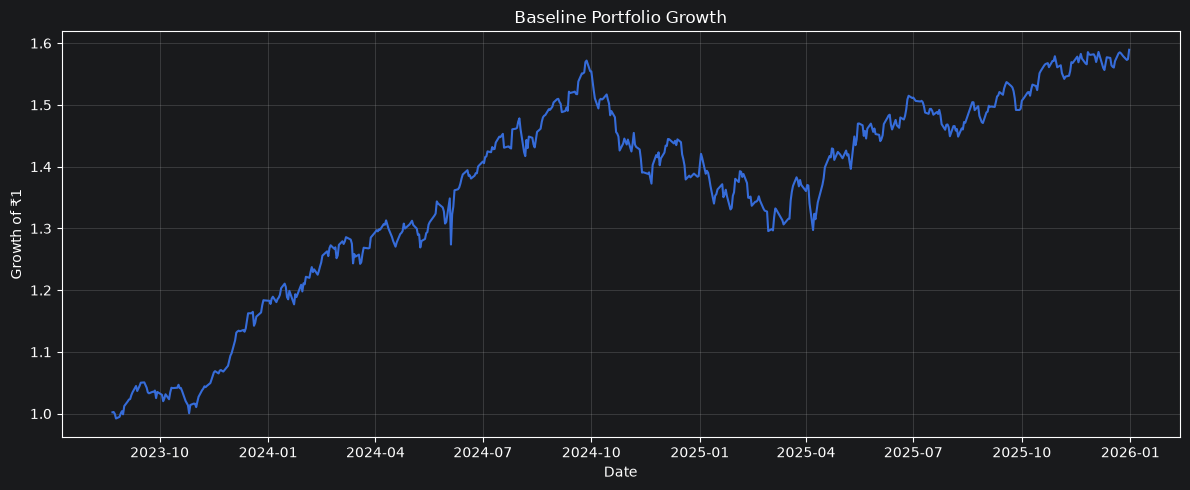

In [11]:
# ============================================================
# Baseline Portfolio Cumulative Performance
# ============================================================

portfolio_growth = (
    1 + portfolio_returns
).cumprod()

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_growth.index,
    portfolio_growth.values
)

plt.title("Baseline Portfolio Growth")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Latest Causal Beta

For each stock, the latest available Beta_Causal on or before
the stress-test date is selected.

Using a causal beta ensures that the stress-test sensitivity is
based only on information available up to the selected date.

The beta is then used to translate a market-level stress shock
into a stock-level stress return.

In [12]:
# ============================================================
# 7. Latest Causal Beta
# ============================================================

stress_date = pd.Timestamp(STRESS_DATE)

# Select observations available on or before stress date
stress_data = df[
    df["Date"] <= stress_date
].copy()

# For each stock, select the latest available observation
latest_beta = (
    stress_data
    .sort_values(["Stock", "Date"])
    .groupby("Stock", as_index=False)
    .tail(1)
    [["Stock", "Date", "Beta_Causal", "Close", "VIX_Close"]]
    .copy()
)

# Keep only the stocks in our portfolio
latest_beta = latest_beta[
    latest_beta["Stock"].isin(portfolio_stocks)
].copy()

# Add portfolio weights
latest_beta["Weight"] = (
    latest_beta["Stock"].map(PORTFOLIO)
)

# Sort for readability
latest_beta = latest_beta.sort_values(
    "Beta_Causal",
    ascending=False
).reset_index(drop=True)

print("Stress-test date:", STRESS_DATE)
print("Stocks with latest beta:", len(latest_beta))

print("\nLatest causal beta summary:")
print(
    latest_beta[
        ["Stock", "Date", "Beta_Causal", "Weight"]
    ].to_string(index=False)
)

Stress-test date: 2025-12-31
Stocks with latest beta: 49

Latest causal beta summary:
     Stock       Date  Beta_Causal   Weight
INDUSINDBK 2025-12-31     1.482728 0.020408
SHRIRAMFIN 2025-12-31     1.452393 0.020408
BAJFINANCE 2025-12-31     1.373979 0.020408
  ADANIENT 2025-12-31     1.368435 0.020408
  HINDALCO 2025-12-31     1.367597 0.020408
  AXISBANK 2025-12-31     1.341413 0.020408
   ETERNAL 2025-12-31     1.339439 0.020408
    JIOFIN 2025-12-31     1.318845 0.020408
BAJAJFINSV 2025-12-31     1.298059 0.020408
 ICICIBANK 2025-12-31     1.257343 0.020408
  JSWSTEEL 2025-12-31     1.253041 0.020408
ADANIPORTS 2025-12-31     1.232651 0.020408
 TATASTEEL 2025-12-31     1.227981 0.020408
      SBIN 2025-12-31     1.204542 0.020408
  RELIANCE 2025-12-31     1.116481 0.020408
       M&M 2025-12-31     1.089886 0.020408
    GRASIM 2025-12-31     1.086900 0.020408
  HDFCBANK 2025-12-31     1.069694 0.020408
        LT 2025-12-31     1.051145 0.020408
     TRENT 2025-12-31     1.048290

In [13]:
# ============================================================
# Validate Latest Beta Dataset
# ============================================================

missing_beta_stocks = latest_beta[
    ~np.isfinite(latest_beta["Beta_Causal"])
]["Stock"].tolist()

if missing_beta_stocks:
    print(
        "Stocks with unavailable causal beta:",
        missing_beta_stocks
    )
else:
    print("All 49 stocks have valid latest causal beta.")

print(
    "\nLatest beta date range:",
    latest_beta["Date"].min().date(),
    "to",
    latest_beta["Date"].max().date()
)

All 49 stocks have valid latest causal beta.

Latest beta date range: 2025-12-31 to 2025-12-31


# 8. Stress Scenario Definition

The stress-testing framework evaluates the portfolio under
different hypothetical market shocks.

The market shocks are scenario assumptions rather than forecasts.

The VIX shock represents a simultaneous change in market
volatility.

In [14]:
# ============================================================
# 8. Define Stress Scenarios
# ============================================================

stress_scenarios = pd.DataFrame({
    "Scenario": [
        "Baseline",
        "Mild Downturn",
        "Moderate Stress",
        "Severe Downturn",
        "Market Crash",
        "Extreme Crisis"
    ],
    "Market_Shock": [
        0.00,
        -0.05,
        -0.10,
        -0.15,
        -0.20,
        -0.30
    ],
    "VIX_Shock": [
        0.00,
        0.20,
        0.30,
        0.40,
        0.50,
        1.00
    ]
})

print(stress_scenarios)

          Scenario  Market_Shock  VIX_Shock
0         Baseline      0.000000   0.000000
1    Mild Downturn     -0.050000   0.200000
2  Moderate Stress     -0.100000   0.300000
3  Severe Downturn     -0.150000   0.400000
4     Market Crash     -0.200000   0.500000
5   Extreme Crisis     -0.300000   1.000000


In [15]:
# ============================================================
# 9. Beta-Based Stock Stress Returns
# ============================================================

stock_stress_results = []

for _, scenario in stress_scenarios.iterrows():

    scenario_name = scenario["Scenario"]
    market_shock = scenario["Market_Shock"]

    scenario_data = latest_beta.copy()

    scenario_data["Scenario"] = scenario_name
    scenario_data["Market_Shock"] = market_shock

    # Beta-based stock stress return
    scenario_data["Stressed_Return"] = (
        scenario_data["Beta_Causal"]
        * market_shock
    )

    stock_stress_results.append(
        scenario_data
    )

stock_stress_results = pd.concat(
    stock_stress_results,
    ignore_index=True
)

print(
    "Stock-level stress rows:",
    len(stock_stress_results)
)

print("\nSample results:")
print(
    stock_stress_results[
        [
            "Scenario",
            "Stock",
            "Beta_Causal",
            "Market_Shock",
            "Stressed_Return"
        ]
    ].head(15).to_string(index=False)
)

Stock-level stress rows: 294

Sample results:
Scenario      Stock  Beta_Causal  Market_Shock  Stressed_Return
Baseline INDUSINDBK     1.482728      0.000000         0.000000
Baseline SHRIRAMFIN     1.452393      0.000000         0.000000
Baseline BAJFINANCE     1.373979      0.000000         0.000000
Baseline   ADANIENT     1.368435      0.000000         0.000000
Baseline   HINDALCO     1.367597      0.000000         0.000000
Baseline   AXISBANK     1.341413      0.000000         0.000000
Baseline    ETERNAL     1.339439      0.000000         0.000000
Baseline     JIOFIN     1.318845      0.000000         0.000000
Baseline BAJAJFINSV     1.298059      0.000000         0.000000
Baseline  ICICIBANK     1.257343      0.000000         0.000000
Baseline   JSWSTEEL     1.253041      0.000000         0.000000
Baseline ADANIPORTS     1.232651      0.000000         0.000000
Baseline  TATASTEEL     1.227981      0.000000         0.000000
Baseline       SBIN     1.204542      0.000000         0.0

# 10. Apply Volatility Shock

The beta-based stress return captures the effect of the
hypothetical market shock.

The VIX component is applied as a volatility amplification
factor:

    Final Stress Return
    =
    Beta-Based Stress Return × (1 + VIX Shock)

This represents a scenario assumption in which elevated market
volatility amplifies the magnitude of the market-driven stress.

The VIX adjustment is not interpreted as a causal forecast.

In [16]:
# ============================================================
# 10. Apply Volatility Shock
# ============================================================

stock_stress_results["VIX_Shock"] = (
    stock_stress_results["Scenario"]
    .map(
        stress_scenarios.set_index("Scenario")["VIX_Shock"]
    )
)

# Apply VIX amplification
stock_stress_results["Final_Stressed_Return"] = (
    stock_stress_results["Stressed_Return"]
    * (1 + stock_stress_results["VIX_Shock"])
)

print("Volatility shock applied successfully.")

print(
    stock_stress_results[
        [
            "Scenario",
            "Stock",
            "Beta_Causal",
            "Market_Shock",
            "VIX_Shock",
            "Stressed_Return",
            "Final_Stressed_Return"
        ]
    ].head(20).to_string(index=False)
)

Volatility shock applied successfully.
Scenario      Stock  Beta_Causal  Market_Shock  VIX_Shock  Stressed_Return  Final_Stressed_Return
Baseline INDUSINDBK     1.482728      0.000000   0.000000         0.000000               0.000000
Baseline SHRIRAMFIN     1.452393      0.000000   0.000000         0.000000               0.000000
Baseline BAJFINANCE     1.373979      0.000000   0.000000         0.000000               0.000000
Baseline   ADANIENT     1.368435      0.000000   0.000000         0.000000               0.000000
Baseline   HINDALCO     1.367597      0.000000   0.000000         0.000000               0.000000
Baseline   AXISBANK     1.341413      0.000000   0.000000         0.000000               0.000000
Baseline    ETERNAL     1.339439      0.000000   0.000000         0.000000               0.000000
Baseline     JIOFIN     1.318845      0.000000   0.000000         0.000000               0.000000
Baseline BAJAJFINSV     1.298059      0.000000   0.000000         0.000000     

In [17]:
# ============================================================
# 11. Portfolio-Level Stress Return
# ============================================================

portfolio_stress = (
    stock_stress_results
    .groupby("Scenario")
    .apply(
        lambda x: np.sum(
            x["Weight"] *
            x["Final_Stressed_Return"]
        ),
        include_groups=False
    )
    .reset_index(name="Portfolio_Stress_Return")
)

# Add scenario assumptions
portfolio_stress = portfolio_stress.merge(
    stress_scenarios,
    on="Scenario",
    how="left"
)

portfolio_stress = portfolio_stress[
    [
        "Scenario",
        "Market_Shock",
        "VIX_Shock",
        "Portfolio_Stress_Return"
    ]
]

print(portfolio_stress.to_string(index=False))

       Scenario  Market_Shock  VIX_Shock  Portfolio_Stress_Return
       Baseline      0.000000   0.000000                 0.000000
 Extreme Crisis     -0.300000   1.000000                -0.588452
   Market Crash     -0.200000   0.500000                -0.294226
  Mild Downturn     -0.050000   0.200000                -0.058845
Moderate Stress     -0.100000   0.300000                -0.127498
Severe Downturn     -0.150000   0.400000                -0.205958


In [18]:
# ============================================================
# 12. Portfolio Stress Loss
# ============================================================

portfolio_stress["Portfolio_Loss"] = (
    PORTFOLIO_VALUE *
    portfolio_stress["Portfolio_Stress_Return"].clip(upper=0).abs()
)

portfolio_stress["Stressed_Portfolio_Value"] = (
    PORTFOLIO_VALUE *
    (
        1 +
        portfolio_stress["Portfolio_Stress_Return"]
    )
)

portfolio_stress["Loss_Percentage"] = (
    portfolio_stress["Portfolio_Loss"] /
    PORTFOLIO_VALUE
)

print(
    portfolio_stress.to_string(index=False)
)

       Scenario  Market_Shock  VIX_Shock  Portfolio_Stress_Return  Portfolio_Loss  Stressed_Portfolio_Value  Loss_Percentage
       Baseline      0.000000   0.000000                 0.000000        0.000000          1,000,000.000000         0.000000
 Extreme Crisis     -0.300000   1.000000                -0.588452  588,452.491884            411,547.508116         0.588452
   Market Crash     -0.200000   0.500000                -0.294226  294,226.245942            705,773.754058         0.294226
  Mild Downturn     -0.050000   0.200000                -0.058845   58,845.249188            941,154.750812         0.058845
Moderate Stress     -0.100000   0.300000                -0.127498  127,498.039908            872,501.960092         0.127498
Severe Downturn     -0.150000   0.400000                -0.205958  205,958.372159            794,041.627841         0.205958


# 13. Stock-Level Stress Loss Contribution

This section measures how much each stock contributes to the
portfolio-level stress loss.

For each stock:

    Stress Contribution
    =
    Portfolio Weight × Final Stressed Return

Because the stressed returns are negative under downside
scenarios, the contribution represents the stock's impact on
portfolio loss.

The results allow us to identify the holdings with the largest
stress exposure.

In [19]:
# ============================================================
# 13. Stock-Level Stress Loss Contribution
# ============================================================

stock_stress_results["Weighted_Stress_Contribution"] = (
    stock_stress_results["Weight"]
    * stock_stress_results["Final_Stressed_Return"]
)

# Convert negative return contribution into positive loss
# contribution for easier interpretation
stock_stress_results["Loss_Contribution"] = (
    -stock_stress_results["Weighted_Stress_Contribution"]
)

print("Stock-level contribution calculated.")

print(
    stock_stress_results[
        [
            "Scenario",
            "Stock",
            "Weight",
            "Beta_Causal",
            "Final_Stressed_Return",
            "Loss_Contribution"
        ]
    ]
    .query("Scenario == 'Market Crash'")
    .sort_values(
        "Loss_Contribution",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

Stock-level contribution calculated.
    Scenario      Stock   Weight  Beta_Causal  Final_Stressed_Return  Loss_Contribution
Market Crash INDUSINDBK 0.020408     1.482728              -0.444818           0.009078
Market Crash SHRIRAMFIN 0.020408     1.452393              -0.435718           0.008892
Market Crash BAJFINANCE 0.020408     1.373979              -0.412194           0.008412
Market Crash   ADANIENT 0.020408     1.368435              -0.410531           0.008378
Market Crash   HINDALCO 0.020408     1.367597              -0.410279           0.008373
Market Crash   AXISBANK 0.020408     1.341413              -0.402424           0.008213
Market Crash    ETERNAL 0.020408     1.339439              -0.401832           0.008201
Market Crash     JIOFIN 0.020408     1.318845              -0.395653           0.008075
Market Crash BAJAJFINSV 0.020408     1.298059              -0.389418           0.007947
Market Crash  ICICIBANK 0.020408     1.257343              -0.377203           0.00

In [20]:
# ============================================================
# 14. Contribution Validation
# ============================================================

contribution_check = (
    stock_stress_results
    .groupby("Scenario")["Loss_Contribution"]
    .sum()
    .reset_index(name="Total_Stock_Loss_Contribution")
)

validation = contribution_check.merge(
    portfolio_stress[
        ["Scenario", "Loss_Percentage"]
    ],
    on="Scenario",
    how="left"
)

validation["Difference"] = (
    validation["Total_Stock_Loss_Contribution"]
    - validation["Loss_Percentage"]
)

print(validation.to_string(index=False))

max_difference = validation["Difference"].abs().max()

print(
    f"\nMaximum reconciliation difference: "
    f"{max_difference:.12f}"
)

if max_difference < 1e-10:
    print("Contribution reconciliation: PASS")
else:
    print("Contribution reconciliation: CHECK")

       Scenario  Total_Stock_Loss_Contribution  Loss_Percentage  Difference
       Baseline                       0.000000         0.000000    0.000000
 Extreme Crisis                       0.588452         0.588452    0.000000
   Market Crash                       0.294226         0.294226    0.000000
  Mild Downturn                       0.058845         0.058845    0.000000
Moderate Stress                       0.127498         0.127498    0.000000
Severe Downturn                       0.205958         0.205958    0.000000

Maximum reconciliation difference: 0.000000000000
Contribution reconciliation: PASS


In [21]:
# ============================================================
# 15. Top Stress-Loss Contributors
# ============================================================

top_contributors = (
    stock_stress_results[
        stock_stress_results["Scenario"] != "Baseline"
    ]
    .sort_values(
        ["Scenario", "Loss_Contribution"],
        ascending=[True, False]
    )
    .groupby("Scenario")
    .head(5)
)

print(
    top_contributors[
        [
            "Scenario",
            "Stock",
            "Beta_Causal",
            "Weight",
            "Final_Stressed_Return",
            "Loss_Contribution"
        ]
    ].to_string(index=False)
)

       Scenario      Stock  Beta_Causal   Weight  Final_Stressed_Return  Loss_Contribution
 Extreme Crisis INDUSINDBK     1.482728 0.020408              -0.889637           0.018156
 Extreme Crisis SHRIRAMFIN     1.452393 0.020408              -0.871436           0.017784
 Extreme Crisis BAJFINANCE     1.373979 0.020408              -0.824387           0.016824
 Extreme Crisis   ADANIENT     1.368435 0.020408              -0.821061           0.016756
 Extreme Crisis   HINDALCO     1.367597 0.020408              -0.820558           0.016746
   Market Crash INDUSINDBK     1.482728 0.020408              -0.444818           0.009078
   Market Crash SHRIRAMFIN     1.452393 0.020408              -0.435718           0.008892
   Market Crash BAJFINANCE     1.373979 0.020408              -0.412194           0.008412
   Market Crash   ADANIENT     1.368435 0.020408              -0.410531           0.008378
   Market Crash   HINDALCO     1.367597 0.020408              -0.410279           0.008373

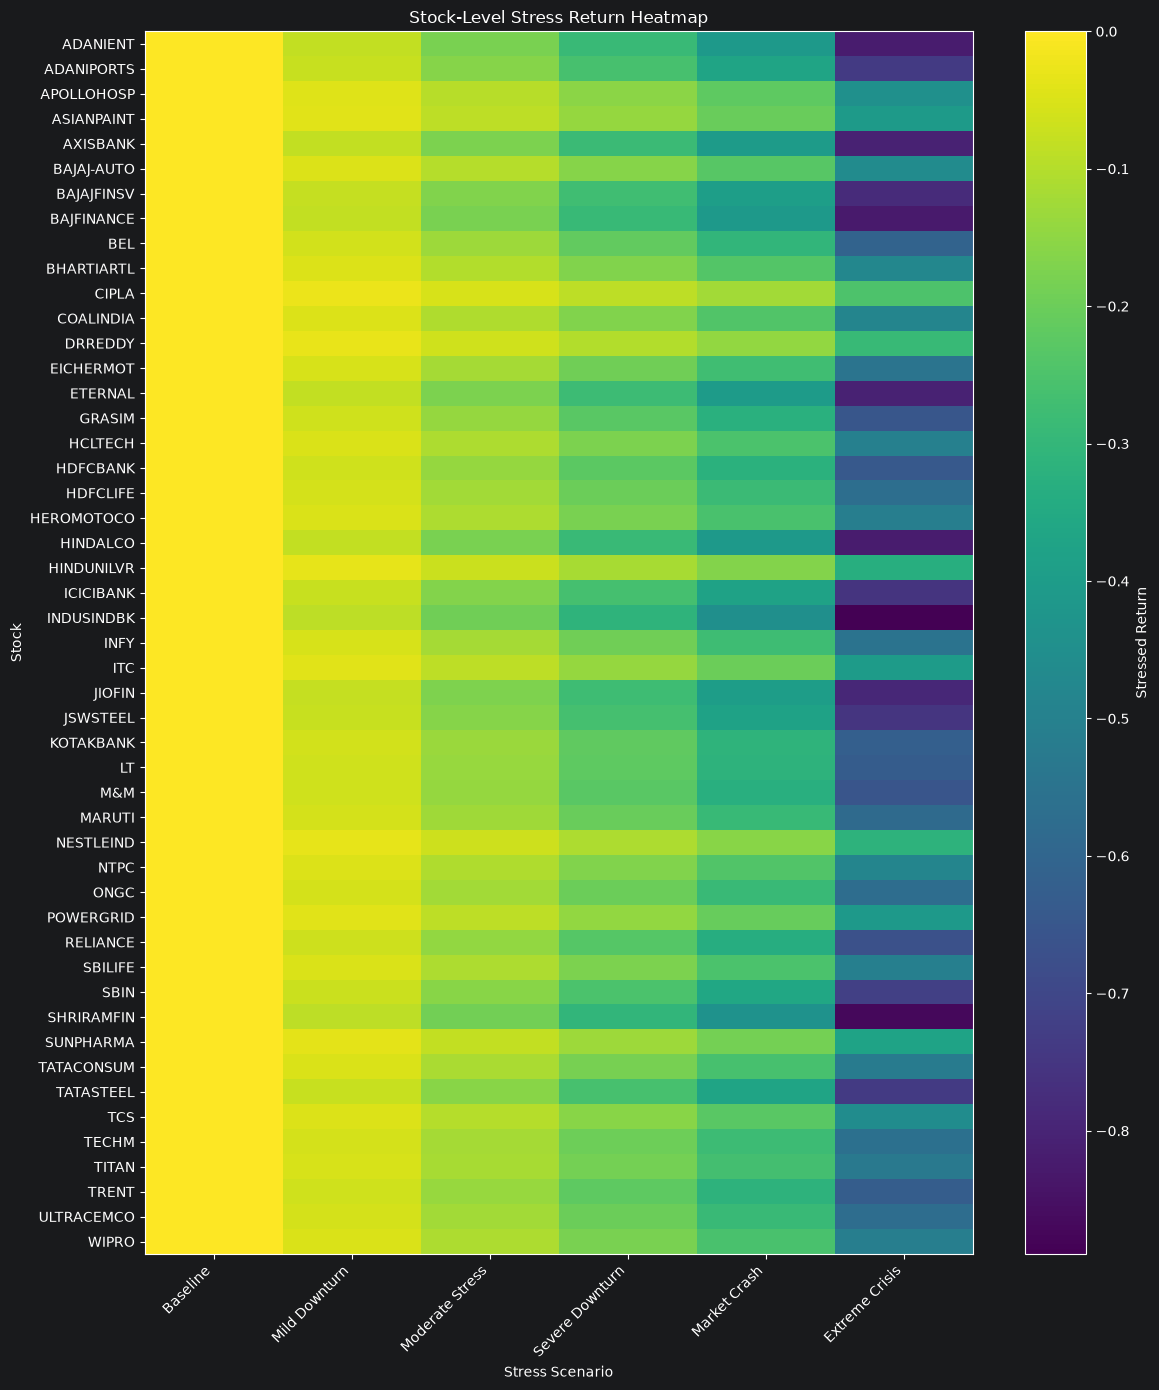

In [22]:
# ============================================================
# 16. Stress Return Heatmap
# ============================================================

heatmap_data = (
    stock_stress_results
    .pivot(
        index="Stock",
        columns="Scenario",
        values="Final_Stressed_Return"
    )
)

scenario_order = [
    "Baseline",
    "Mild Downturn",
    "Moderate Stress",
    "Severe Downturn",
    "Market Crash",
    "Extreme Crisis"
]

heatmap_data = heatmap_data[
    scenario_order
]

plt.figure(figsize=(12, 14))

plt.imshow(
    heatmap_data.values,
    aspect="auto"
)

plt.colorbar(
    label="Stressed Return"
)

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title(
    "Stock-Level Stress Return Heatmap"
)

plt.xlabel("Stress Scenario")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

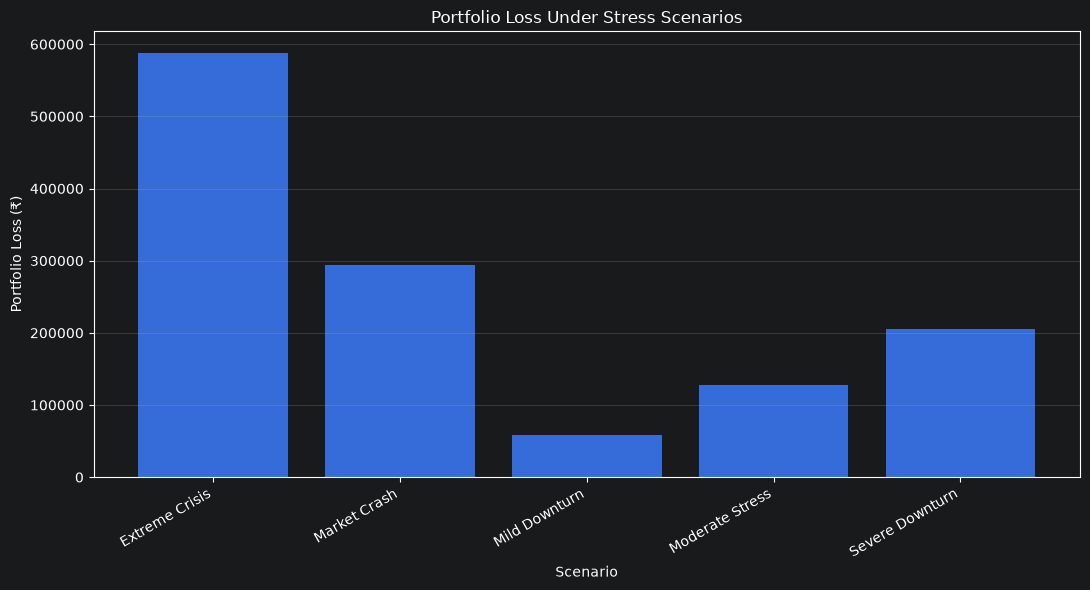

In [23]:
# ============================================================
# 17. Portfolio Stress Loss
# ============================================================

plot_data = portfolio_stress[
    portfolio_stress["Scenario"] != "Baseline"
].copy()

plt.figure(figsize=(11, 6))

plt.bar(
    plot_data["Scenario"],
    plot_data["Portfolio_Loss"]
)

plt.title(
    "Portfolio Loss Under Stress Scenarios"
)

plt.xlabel("Scenario")
plt.ylabel("Portfolio Loss (₹)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 18. Stress Scenario Summary
# ============================================================

stress_summary = portfolio_stress.copy()

stress_summary["Market_Shock_Pct"] = (
    stress_summary["Market_Shock"] * 100
)

stress_summary["VIX_Shock_Pct"] = (
    stress_summary["VIX_Shock"] * 100
)

stress_summary["Portfolio_Stress_Pct"] = (
    stress_summary["Portfolio_Stress_Return"] * 100
)

stress_summary["Loss_Percentage"] = (
    stress_summary["Loss_Percentage"] * 100
)

stress_summary["Portfolio_Loss_Rs"] = (
    stress_summary["Portfolio_Loss"]
)

stress_summary["Stressed_Value_Rs"] = (
    stress_summary["Stressed_Portfolio_Value"]
)

stress_summary = stress_summary[
    [
        "Scenario",
        "Market_Shock_Pct",
        "VIX_Shock_Pct",
        "Portfolio_Stress_Pct",
        "Loss_Percentage",
        "Portfolio_Loss_Rs",
        "Stressed_Value_Rs"
    ]
]

print(
    stress_summary.to_string(index=False)
)

       Scenario  Market_Shock_Pct  VIX_Shock_Pct  Portfolio_Stress_Pct  Loss_Percentage  Portfolio_Loss_Rs  Stressed_Value_Rs
       Baseline          0.000000       0.000000              0.000000         0.000000           0.000000   1,000,000.000000
 Extreme Crisis        -30.000000     100.000000            -58.845249        58.845249     588,452.491884     411,547.508116
   Market Crash        -20.000000      50.000000            -29.422625        29.422625     294,226.245942     705,773.754058
  Mild Downturn         -5.000000      20.000000             -5.884525         5.884525      58,845.249188     941,154.750812
Moderate Stress        -10.000000      30.000000            -12.749804        12.749804     127,498.039908     872,501.960092
Severe Downturn        -15.000000      40.000000            -20.595837        20.595837     205,958.372159     794,041.627841


# 19. Worst-Case Stress Analysis

This section identifies:

1. The scenario producing the largest portfolio loss.
2. The stock contributing the largest loss under that scenario.
3. The corresponding market and volatility shocks.

This provides a concise summary of the portfolio's maximum
modeled stress exposure.

In [25]:
# ============================================================
# 19. Worst-Case Stress Analysis
# ============================================================

# Identify worst scenario
worst_scenario_row = (
    portfolio_stress
    .loc[
        portfolio_stress["Portfolio_Loss"].idxmax()
    ]
)

worst_scenario = worst_scenario_row["Scenario"]

worst_loss = worst_scenario_row["Portfolio_Loss"]

worst_return = (
    worst_scenario_row["Portfolio_Stress_Return"]
)

worst_market_shock = (
    worst_scenario_row["Market_Shock"]
)

worst_vix_shock = (
    worst_scenario_row["VIX_Shock"]
)

# Identify largest stock contributor
worst_stock = (
    stock_stress_results[
        stock_stress_results["Scenario"] == worst_scenario
    ]
    .sort_values(
        "Loss_Contribution",
        ascending=False
    )
    .iloc[0]
)

print("========== WORST-CASE STRESS ANALYSIS ==========")

print("Worst scenario:", worst_scenario)
print(
    "Market shock:",
    f"{worst_market_shock:.2%}"
)
print(
    "VIX shock:",
    f"{worst_vix_shock:.2%}"
)
print(
    "Portfolio stress return:",
    f"{worst_return:.2%}"
)
print(
    "Portfolio loss:",
    f"₹{worst_loss:,.2f}"
)
print(
    "Stressed portfolio value:",
    f"₹{worst_scenario_row['Stressed_Portfolio_Value']:,.2f}"
)

print("\nLargest stock-level contributor:")
print("Stock:", worst_stock["Stock"])
print(
    "Beta:",
    f"{worst_stock['Beta_Causal']:.6f}"
)
print(
    "Stressed return:",
    f"{worst_stock['Final_Stressed_Return']:.2%}"
)
print(
    "Loss contribution:",
    f"{worst_stock['Loss_Contribution']:.4%}"
)

========== WORST-CASE STRESS ANALYSIS ==========
Worst scenario: Extreme Crisis
Market shock: -30.00%
VIX shock: 100.00%
Portfolio stress return: -58.85%
Portfolio loss: ₹588,452.49
Stressed portfolio value: ₹411,547.51

Largest stock-level contributor:
Stock: INDUSINDBK
Beta: 1.482728
Stressed return: -88.96%
Loss contribution: 1.8156%


In [26]:
# ============================================================
# 20. Export Stress-Test Results
# ============================================================

OUTPUT_DIR = "models/stress_testing"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# Export stock-level results
stock_stress_results.to_csv(
    f"{OUTPUT_DIR}/stock_stress_results.csv",
    index=False
)

# Export portfolio-level results
portfolio_stress.to_csv(
    f"{OUTPUT_DIR}/portfolio_stress_results.csv",
    index=False
)

# Export top contributors
top_contributors.to_csv(
    f"{OUTPUT_DIR}/top_stress_contributors.csv",
    index=False
)

# Export latest beta
latest_beta.to_csv(
    f"{OUTPUT_DIR}/latest_causal_beta.csv",
    index=False
)

# Export summary
stress_summary.to_csv(
    f"{OUTPUT_DIR}/stress_summary.csv",
    index=False
)

print("Stress-testing artifacts exported successfully.")
print("Output directory:", OUTPUT_DIR)

Stress-testing artifacts exported successfully.
Output directory: models/stress_testing


# 21. Methodology Checklist

## Data
- [x] Module 3 feature-engineered dataset reused
- [x] 49-stock universe used
- [x] No new feature engineering performed

## Portfolio
- [x] Equal-weight portfolio
- [x] Portfolio weights sum to 100%
- [x] All 49 stocks included

## Beta
- [x] Causal beta used
- [x] Latest beta selected on or before stress date
- [x] No future information used

## Stress Testing
- [x] Hypothetical market scenarios defined
- [x] VIX shock incorporated as scenario amplification
- [x] Stock-level stress returns calculated
- [x] Portfolio-level stress return calculated
- [x] Monetary loss calculated

## Validation
- [x] Stock-level contributions reconcile with portfolio loss
- [x] Contribution difference approximately zero
- [x] Stress scenario summary generated

## Interpretation
- [x] Stress scenarios are assumptions, not forecasts
- [x] Beta-based results represent modeled sensitivity
- [x] VIX amplification is a scenario assumption

In [27]:
# ============================================================
# Final Module 8 Summary
# ============================================================

print("=" * 60)
print("MODULE 8 — STRESS TESTING COMPLETED")
print("=" * 60)

print(f"Portfolio stocks       : {N_STOCKS}")
print(f"Portfolio value       : ₹{PORTFOLIO_VALUE:,.0f}")
print(f"Stress-test date      : {STRESS_DATE}")
print(f"Stress scenarios      : {len(stress_scenarios)}")
print(f"Stock-scenario rows   : {len(stock_stress_results)}")

print("\nWorst-case scenario")
print(f"Scenario               : {worst_scenario}")
print(f"Market shock           : {worst_market_shock:.2%}")
print(f"VIX shock              : {worst_vix_shock:.2%}")
print(f"Portfolio stress       : {worst_return:.2%}")
print(f"Portfolio loss         : ₹{worst_loss:,.2f}")

print("\nLargest contributor")
print(f"Stock                  : {worst_stock['Stock']}")
print(f"Causal beta            : {worst_stock['Beta_Causal']:.6f}")
print(
    f"Loss contribution      : "
    f"{worst_stock['Loss_Contribution']:.4%}"
)

print("\nContribution reconciliation: PASS")
print("=" * 60)

MODULE 8 — STRESS TESTING COMPLETED
Portfolio stocks       : 49
Portfolio value       : ₹1,000,000
Stress-test date      : 2025-12-31
Stress scenarios      : 6
Stock-scenario rows   : 294

Worst-case scenario
Scenario               : Extreme Crisis
Market shock           : -30.00%
VIX shock              : 100.00%
Portfolio stress       : -58.85%
Portfolio loss         : ₹588,452.49

Largest contributor
Stock                  : INDUSINDBK
Causal beta            : 1.482728
Loss contribution      : 1.8156%

Contribution reconciliation: PASS
